# Part 3: Alternating Least Squares Model

A common type of recommender system is *collaborative filtering*, where the
system suggests items to users based on the preferences/behavior of similar
users. In other words, it looks at similar users, which items they enjoy, and
makes recommendations based off of this.

A common collaborative filtering model is *Alternating Least Squares*,
developed by Yifan Hu et al in their 2007 paper
[Collaborative Filtering for Implicit Feedback Datasets][1]. This model seeks
to factorize the user-item matrix into matrices of latent user factors and
latent item factors. For a quick synopsis of the model, take a look at
[this Medium article by Everton Gomede][2].

Fortunately, we don't have to implement this model from scratch. We can use
the `implicit` library in python for a simple implementation using SciPy's
CSR Matrix.

[1]: http://yifanhu.net/PUB/cf.pdfd
[2]: https://medium.com/aimonks/alternating-least-squares-a-cornerstone-in-modern-data-analysis-and-recommendation-systems-ceb7310313f9

In [84]:
import itertools
from pathlib import Path

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from implicit.cpu.als import AlternatingLeastSquares as ALSModel
from numpy.typing import NDArray
from scipy.sparse import csr_matrix
from sklearn.metrics import ndcg_score

In [27]:
# Directories
root_dir = Path().resolve().parent
data_dir = root_dir / 'data'
final_data_dir = data_dir / 'final'

train_path = final_data_dir / 'user_items_1p_sample_train.feather'
valid_path = final_data_dir / 'user_items_1p_sample_val.feather'
test_path = final_data_dir / 'user_items_1p_sample_test.feather'
metadata_path = final_data_dir / 'user_items_1p_sample_meta.json'

In [28]:
# Constants
USER_COL = 'user_id'
ITEM_COL = 'item_id'
RATING_COL = 'playtime'

## Load Data

Since we already have the data preprocessed and split into train/test sets, we
can import these and go straight to modeling. For faster results, we'll use the
1% sample to work with this model.

In [29]:
def get_user_item_csr_matrix(
        df: pd.DataFrame,
        n_users: int,
        n_items: int,
) -> csr_matrix:
    ratings = df.pivot(index=USER_COL, columns=ITEM_COL, values=RATING_COL)
    observed_users = ratings.index.values.reshape(-1, 1)
    observed_items = ratings.columns.values

    R = np.full(shape=(n_users, n_items), fill_value=0.0)
    R[observed_users, observed_items] = ratings.values
    R[np.isnan(R)] = 0
    return csr_matrix(R)


meta = pd.read_json(metadata_path, orient='index').iloc[:, 0]
n_users = int(meta.n_users)
n_items = int(meta.n_items)

df_train = pd.read_feather(train_path)
df_valid = pd.read_feather(valid_path)
df_test = pd.read_feather(test_path)
R_train = get_user_item_csr_matrix(df_train, n_users, n_items)
R_valid = get_user_item_csr_matrix(df_train, n_users, n_items)
R_test = get_user_item_csr_matrix(df_test, n_users, n_items)

display(meta)

n_users          573.00
n_items         4110.00
sample_frac        0.01
test_size          0.20
valid_size         0.20
random_state       0.00
Name: 0, dtype: float64

## Model Implementation

The model is straightforward to use, though at the time of writing this, the
`implicit` evaluation tools are not working well. However, we can make use of
Scikit-Learn's metrics for now, with a small addition to calculate the
users-item recommendations.

In [19]:
class LossCallback:
    '''
    Stores loss data over the training iterations.
    '''
    def __init__(self) -> None:
        self.iterations = []
        self.losses = []
        return
    
    def __call__(
            self,
            iteration: int,
            time: float,
            loss: float,
    ) -> None:
        self.iterations.append(iteration)
        self.losses.append(loss)
        return

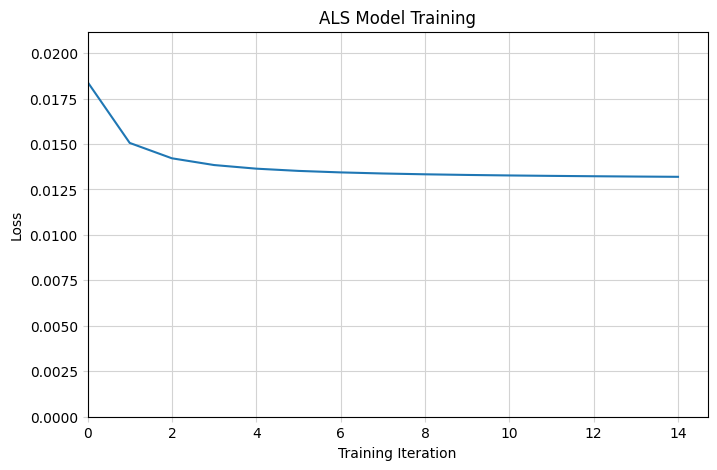

In [30]:
# Parameters
factors = 32
epochs = 15

loss_callback = LossCallback()

model = ALSModel(
    factors,
    iterations=epochs,
    calculate_training_loss=True,
    random_state=0,
)

model.fit(R_train, show_progress=False, callback=loss_callback)
losses = loss_callback.losses

# Plot training
fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(losses)
ax.set_title(f'ALS Model Training')
ax.set_xlabel('Training Iteration')
ax.set_ylabel('Loss')

ax.set_xlim(0)
ax.set_ylim(0, max(losses) * 1.15)
ax.grid(color='lightgray')
ax.tick_params(color='lightgray')
ax.set_axisbelow(True)

plt.show()

## Hyperparameter Tuning

Let's work with some of the hyperparameters to try to get a best-fit model.
There's a few things we can work with:

1. Number of Latent Factors
2. Regularization Coefficient
3. Positive Example Weight (Alpha)

Let's do a grid search to see how the model performs on each and select the
best parameters.

**Note:** The loss calculated is an adjusted version of mean-squared error,
as written by Hu et al in their paper:

$$
\mathcal{L}(X,Y)
\sum_{u,i} c_{ui},\big(p_{ui} - x_u^\top y_i\big)^2
;+;
\lambda\left(\sum_u |x_u|^2 + \sum_i |y_i|^2\right)
$$

Where:

- $p_{ui}$ is a **binary preference**:
  - $p_{ui} = 1$ if the interaction is present
  - $p_{ui} = 0$ if the interaction is missing
- $c_{ui}$ is a **confidence weight**:
  - for missing entries, $c_{ui} = 1$
  - for observed entries, $c_{ui} > 1$ (or generally larger)

In [31]:
def predict_als(model: ALSModel, R_true: csr_matrix) -> NDArray:
    '''
    Calculates the predicted ratings from the ALS model, setting non-observed
    elements to 0.
    '''
    R_pred = model.user_factors @ model.item_factors.T
    R_pred[R_true.toarray() == 0] = 0
    return R_pred

In [65]:
from itertools import product
from tqdm.auto import tqdm


class ALSGridSearch:
    '''
    A class to store the variables for a grid search.
    '''
    def __init__(
            self,
            R_train: csr_matrix,
            R_valid: csr_matrix,
            iterations: int = 15,
            random_state: int | None = None,
    ) -> None:
        self.R_train = R_train
        self.R_valid = R_valid
        self.iterations = iterations
        self.random_state = random_state
        return
    
    def run(
            self,
            factors: list[int],
            regularization: list[float],
            alpha: list[float],
            verbose: bool = True,
    ) -> pd.DataFrame:
        parameters = list(product(factors, regularization, alpha))
        if verbose:
            parameters = tqdm(parameters, 'Running grid search')
        
        results = []
        for f, lambda_, a in parameters:
            loss, metric = self._run_once(f, lambda_, a)
            results.append([loss, metric])

        df = pd.DataFrame(parameters)
        df.columns = ['factors', 'regularization', 'alpha']
        df[['loss', 'metric']] = results
        return df
    
    def _run_once(
            self,
            factors: int,
            regularization: float,
            alpha: float,
    ) -> tuple[float, float]:
        loss_callback = LossCallback()
        model = ALSModel(
            factors = factors,
            regularization = regularization,
            alpha = alpha,
            iterations = self.iterations,
            calculate_training_loss = True,
            random_state = self.random_state,
        )
        model.fit(self.R_train, show_progress=False, callback=loss_callback)
        R_pred = predict_als(model, self.R_valid)
        loss = loss_callback.losses[-1]
        metric = ndcg_score(self.R_valid.toarray(), R_pred, k=10)
        return loss, metric

In [109]:
grid_search = ALSGridSearch(R_train, R_valid, 15, random_state=0)
gs_results = grid_search.run(
    factors = [16, 24, 32, 48, 64],
    regularization = [0.001, 0.01, 0.1, 10., 100.],
    alpha = [0.1, 0.5, 1., 5., 10.],
)

gs_results.sort_values('metric', ascending=False).head()

Running grid search:   0%|          | 0/125 [00:00<?, ?it/s]

,factors,regularization,alpha,loss,metric
116,64,10.0,0.5,0.012502,0.894715
91,48,10.0,0.5,0.012830,0.890359
66,32,10.0,0.5,0.013356,0.886525
117,64,10.0,1.0,0.016469,0.886242
41,24,10.0,0.5,0.013728,0.884732


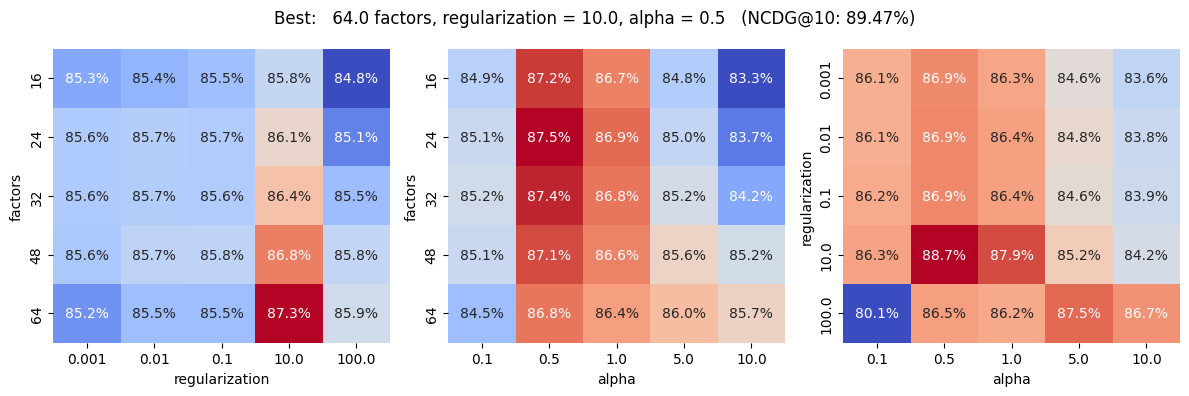

In [110]:
fig = plt.figure(figsize=(12, 4))

param_names = ['factors', 'regularization', 'alpha']

for i, (p1, p2) in enumerate(itertools.combinations(param_names, r=2), start=1):
    ax = fig.add_subplot(1, 3, i)
    sns.heatmap(
        ax = ax,
        data = gs_results.pivot_table(
            index = p1,
            columns = p2,
            values = 'metric',
            aggfunc = 'mean',
            fill_value = 0
        ),
        annot = True,
        cmap = 'coolwarm',
        cbar = False,
        fmt = '.1%',
    )

# Show best option in title
best_params = gs_results.loc[gs_results['metric'].argmax()]
plt.suptitle(
    'Best:   {} factors, regularization = {}, alpha = {}   (NCDG@10: {:.2%})'
    .format(
        best_params.factors,
        best_params.regularization,
        best_params.alpha,
        best_params.metric,
    )
)

plt.tight_layout()
plt.show()

## Final Training

Let's do the final training using the test dataset.

In [111]:
R_train_full = R_train + R_valid   # Since no overlap, only 0 for non-observed

model = ALSModel(
    factors = 64,
    regularization = 10.0,
    alpha = 0.5,
    iterations = 15,
    random_state = 0,
)
model.fit(R_train_full, show_progress = False)
R_pred = predict_als(model, R_test)
R_true = R_test.toarray()

ndcg_10 = ndcg_score(R_true, R_pred, k=10)
print(f'Final NDCG@10:  {ndcg_10:.2%}')

Final NDCG@10:  79.79%
